# Compare Model Distributions

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import bayesflow as bf
import bayesflow.diagnostics.plots as bf_plots
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from confrdm.simulators.custom import CustomSimulator
from confrdm.simulators.dmc import sample_dmc_prior
from confrdm.simulators.dmc import simulate_dmc
from confrdm.simulators.rdmc import sample_rdmc_prior_two_accumulators
from confrdm.simulators.rdmc import simulate_rdmc_two_accumulators
from confrdm.utils import sample_random_num_obs

INFO:2026-01-15 10:47:47,911:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


In [3]:
T_MAX = 5000

NUM_SIMS = 500
NUM_OBS = 1000

rng = np.random.default_rng(2026)

In [4]:
def sample_random_num_obs_partial(batch_shape):
    return sample_random_num_obs(batch_shape, rng)

num_obs_simulator = bf.simulators.LambdaSimulator(sample_random_num_obs_partial, is_batched=True)

## DMC

In [5]:
def simulate_dmc_partial(**kwargs):
    return simulate_dmc(**kwargs, alpha=0.0, a_shape=2.0, s=1.0, t_max=T_MAX)

param_names = ["v_c", "amp", "tau", "b", "t0"]

dmc_simulator = CustomSimulator(
    prior_simulator=bf.simulators.LambdaSimulator(sample_dmc_prior),
    design_simulator=num_obs_simulator,
    experiment_simulator=bf.simulators.LambdaSimulator(simulate_dmc_partial),
)

In [6]:
dmc_sims = dmc_simulator.sample((NUM_SIMS,), num_obs=NUM_OBS)

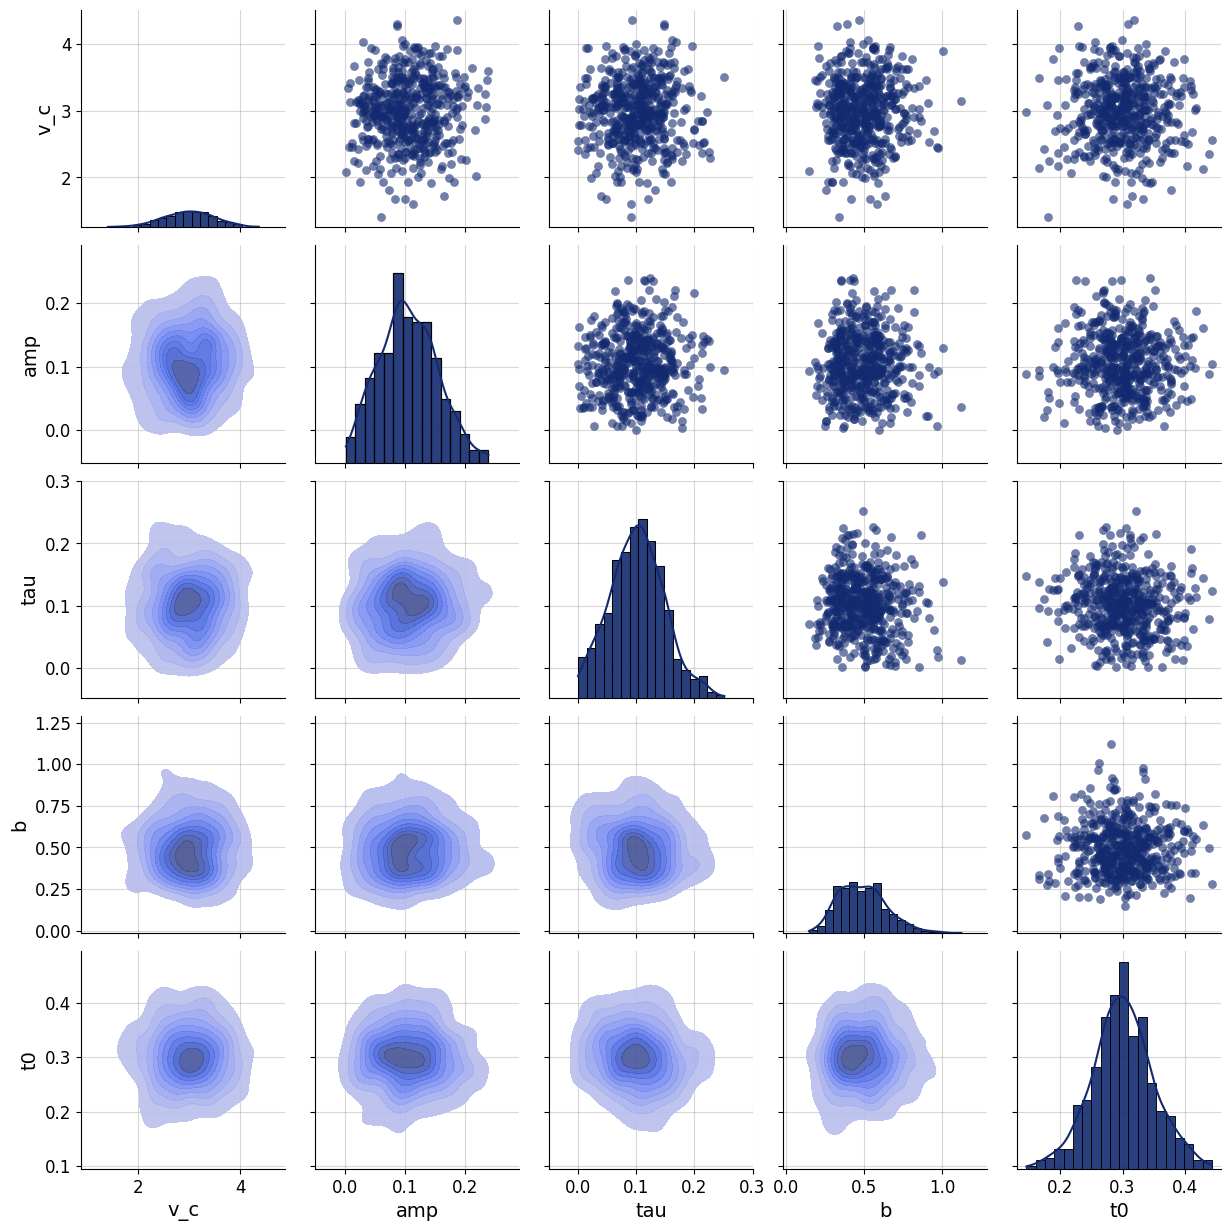

In [7]:
_ = bf_plots.pairs_samples(dmc_sims, variable_keys=param_names, variable_names=param_names)

In [8]:
def create_pushforward_plot(data, max_subplots=10):
    num_sims = min(data.shape[0], max_subplots)

    fig, axarr = plt.subplots(2, num_sims // 2, figsize=(20, 5))
    rt = data[:, :, 0]
    resp = data[:, :, 1]

    for i, ax in enumerate(axarr.flatten()):
        sns.histplot(
            rt[i][resp[i] == 1], color="darkgreen", alpha=0.5, ax=ax,
        )
        sns.histplot(
            rt[i][resp[i] == 0], color="maroon", alpha=0.5, ax=ax,
        )
        sns.despine(ax=ax)
        ax.vlines(
            [rt[i][resp[i] == 1].mean(), rt[i][resp[i] == 0].mean()],
            ymin = 0, ymax = 0.5, color = ["darkgreen", "maroon"], linestyle = "-",
            transform=ax.get_xaxis_transform(),
        )

        ax.text(
            0.9,
            0.9,
            f"Acc: {np.round(resp[i].mean(), 3)!s}",
            horizontalalignment="center",
            verticalalignment="center",
            transform=ax.transAxes,
        )

        ax.spines["bottom"].set_position("zero")

        ax.set_ylabel("")
        ax.set_yticks([])
        ax.set_xlabel("Simulated RTs (milliseconds)")

    fig.tight_layout()

    return fig, ax

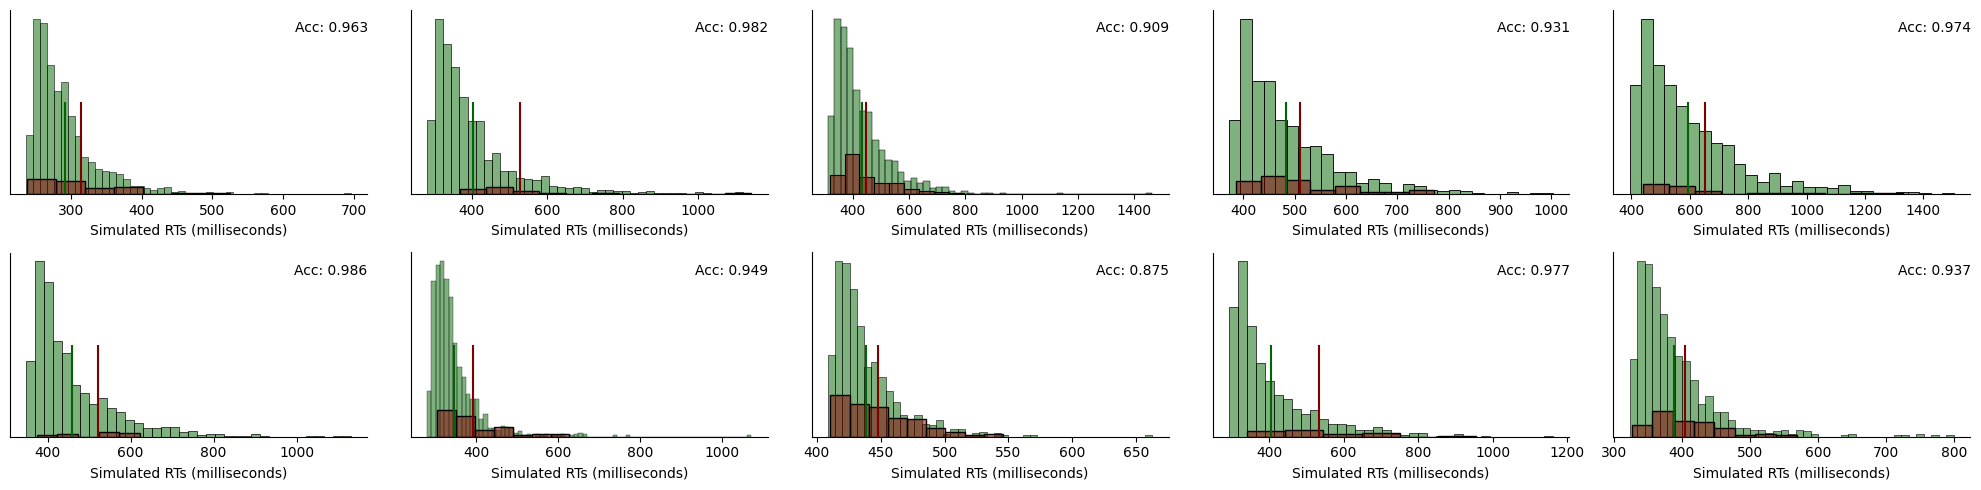

In [9]:
_ = create_pushforward_plot(dmc_sims["x"])

In [10]:
def create_accuracy_plot(data):
    acc = data[:, :, 1].mean(axis=1)

    fig, ax = plt.subplots(1, 1)

    sns.histplot(acc, ax=ax)

    ax.spines["bottom"].set_position("zero")

    ax.set_ylabel("")
    ax.set_yticks([])
    ax.set_xlabel("Simulated dataset accuracies")

    return fig, ax

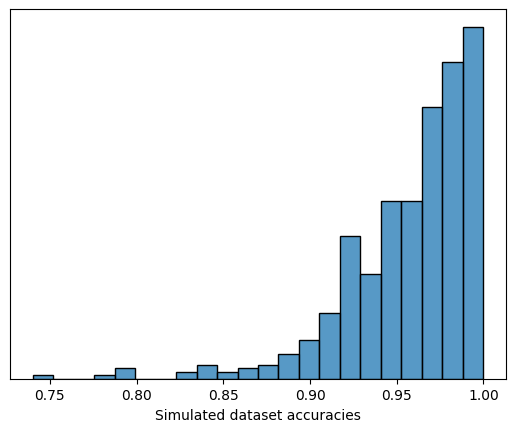

In [11]:
_ = create_accuracy_plot(dmc_sims["x"])

In [12]:
def create_rt_quantile_plot(data):
    rt = data[:, :, 0]

    quantile_true = np.quantile(rt, q=[0.0, 0.25, 0.5, 0.75, 1.0], axis=1)

    print(quantile_true.shape)

    fig, ax = plt.subplots(1, 1)

    sns.boxplot(quantile_true.T, ax=ax)

    ax.spines["bottom"].set_position("zero")

    ax.set_ylabel("Simulated quantile RT")
    ax.set_xlabel("Simulated dataset quantiles")
    ax.set_xticklabels(["Min", "25th", "50th", "75th", "Max"])

    return fig, ax

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


(5, 500)


/tmp/ipykernel_22446/1948064468.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Min", "25th", "50th", "75th", "Max"])


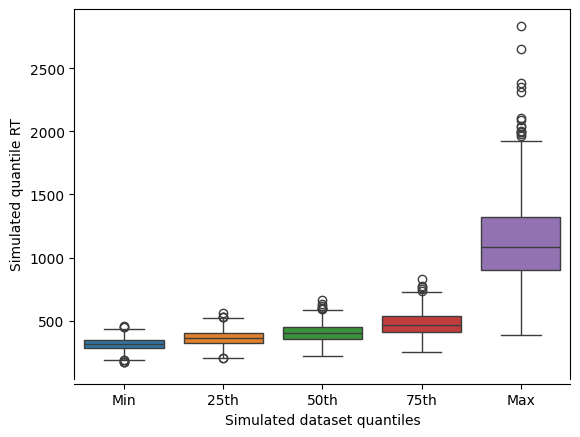

In [13]:
_ = create_rt_quantile_plot(dmc_sims["x"])

## CRDM

In [16]:
def simulate_rdmc_partial(**kwargs):
    return simulate_rdmc_two_accumulators(**kwargs, a_shape=2.0, s_false=1.0, t_max=T_MAX)

param_names = ["v_c_intercept", "v_c_slope", "amp", "tau", "s_true", "b", "t0"]

crdm_simulator = CustomSimulator(
    prior_simulator=bf.simulators.LambdaSimulator(sample_rdmc_prior_two_accumulators),
    design_simulator=num_obs_simulator,
    experiment_simulator=bf.simulators.LambdaSimulator(simulate_rdmc_partial),
)

In [17]:
crdm_sims = crdm_simulator.sample((NUM_SIMS,), num_obs=NUM_OBS)

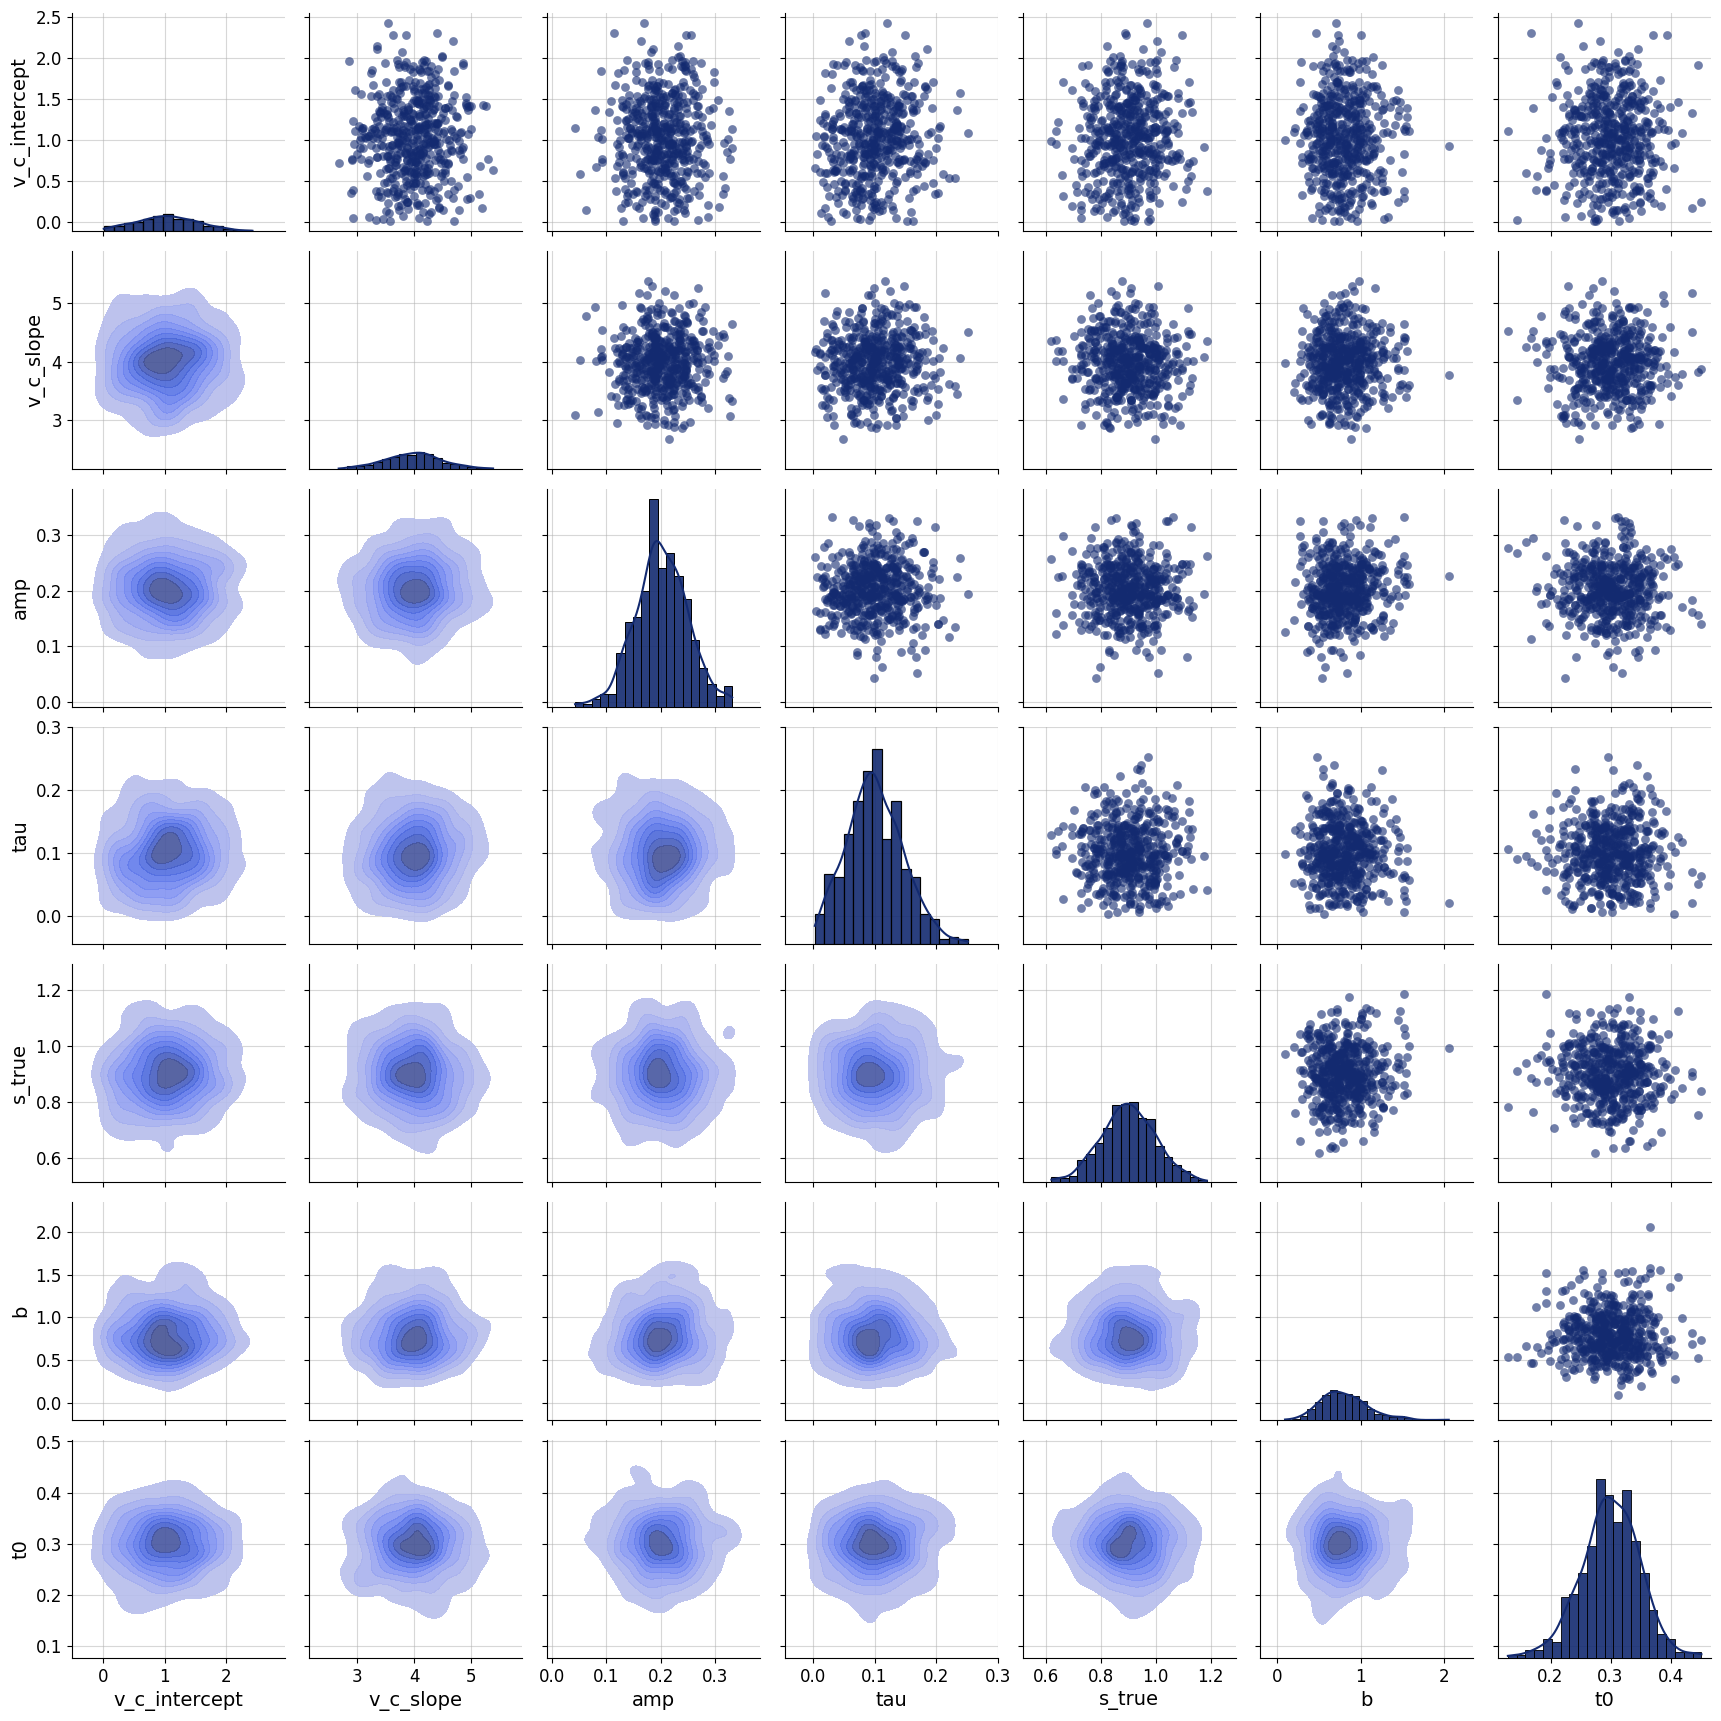

In [18]:
_ = bf_plots.pairs_samples(crdm_sims, variable_keys=param_names, variable_names=param_names)

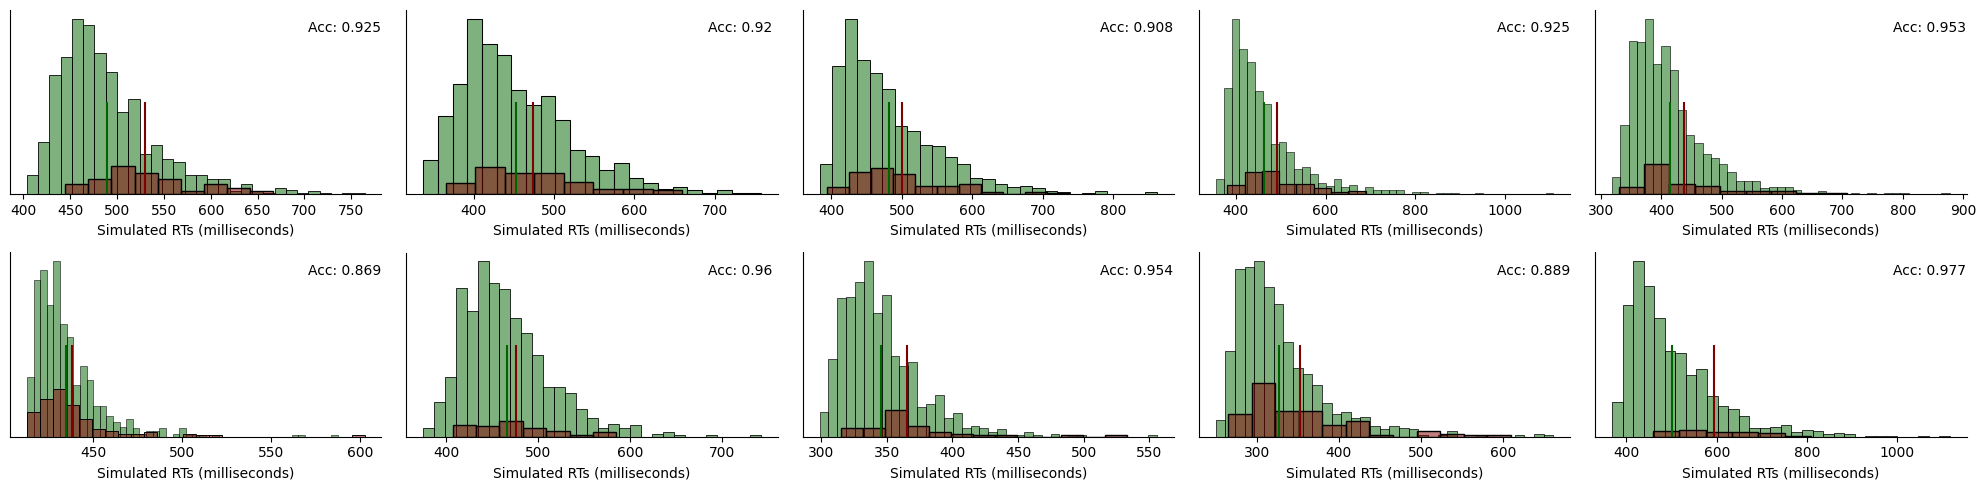

In [19]:
_ = create_pushforward_plot(crdm_sims["x"])

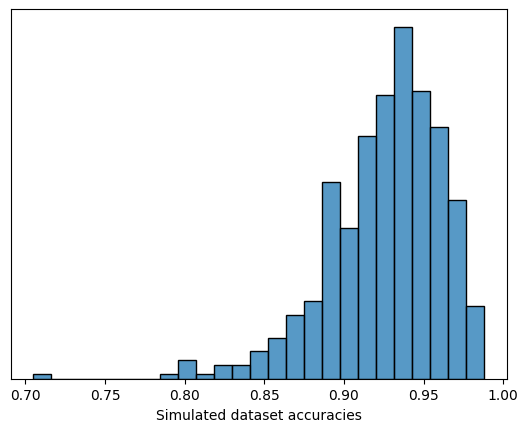

In [20]:
_ = create_accuracy_plot(crdm_sims["x"])

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


(5, 500)


/tmp/ipykernel_22446/1948064468.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Min", "25th", "50th", "75th", "Max"])


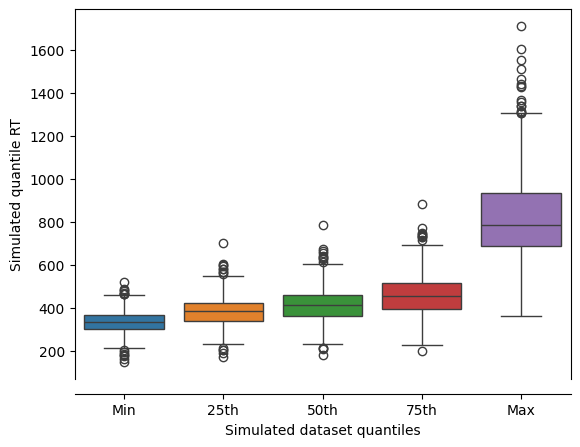

In [21]:
_ = create_rt_quantile_plot(crdm_sims["x"])

## CRDM (without conflict)

In [22]:
def simulate_rdm_partial(**kwargs):
    kwargs.pop("amp")
    return simulate_rdmc_two_accumulators(**kwargs, amp=0.0, a_shape=2.0, s_false=1.0, t_max=T_MAX)

param_names = ["v_c_intercept", "v_c_slope", "tau", "s_true", "b", "t0"]

rdm_simulator = CustomSimulator(
    prior_simulator=bf.simulators.LambdaSimulator(sample_rdmc_prior_two_accumulators),
    design_simulator=num_obs_simulator,
    experiment_simulator=bf.simulators.LambdaSimulator(simulate_rdm_partial),
)

In [23]:
rdm_sims = rdm_simulator.sample((NUM_SIMS,), num_obs=NUM_OBS)

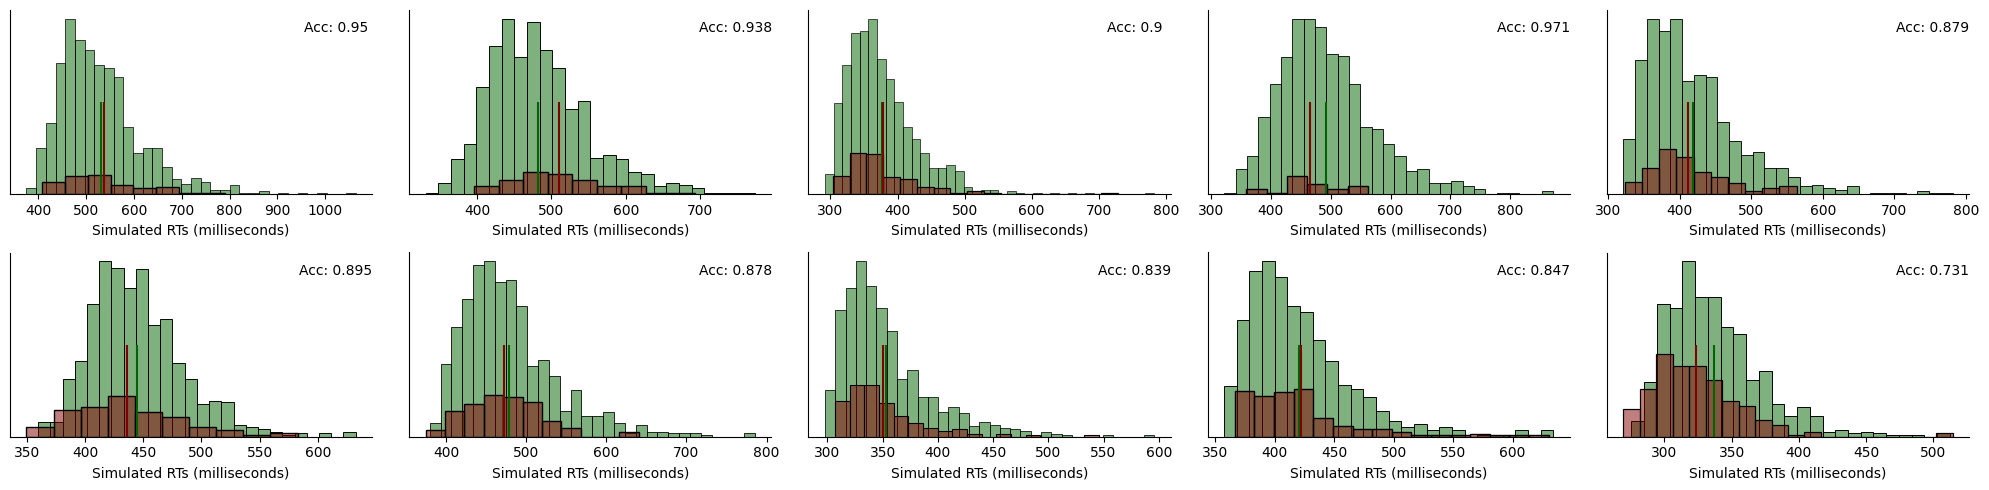

In [24]:
_ = create_pushforward_plot(rdm_sims["x"])

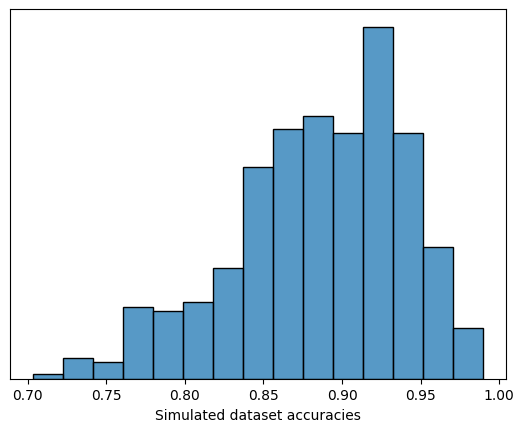

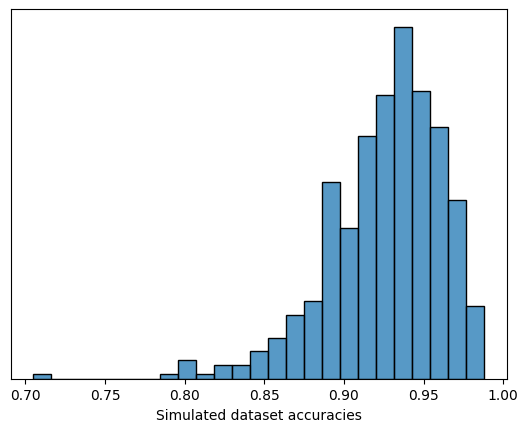

In [25]:
_ = create_accuracy_plot(rdm_sims["x"])
_ = create_accuracy_plot(crdm_sims["x"])

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/tmp/ipykernel_22446/1948064468.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Min", "25th", "50th", "75th", "Max"])
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these s

(5, 500)
(5, 500)


/tmp/ipykernel_22446/1948064468.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Min", "25th", "50th", "75th", "Max"])


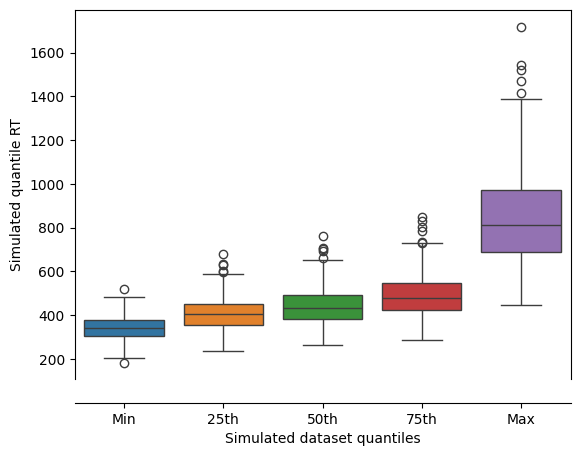

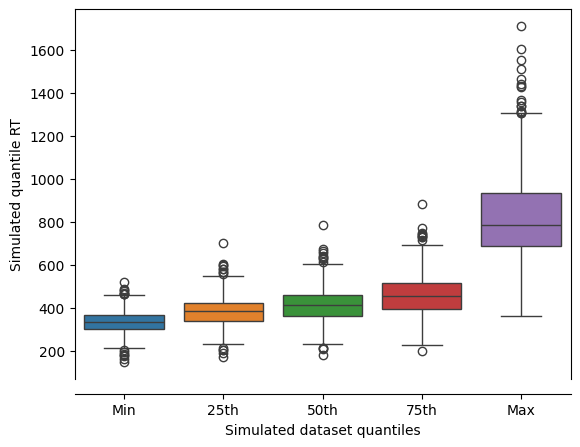

In [26]:
_ = create_rt_quantile_plot(rdm_sims["x"])
_ = create_rt_quantile_plot(crdm_sims["x"])